# APLICANDO DATA AUGMENTATION PARA INCREMENTAR EL NRO DE IMAGENES

# 1 - GARGAMOS IMAGENES PARA EL DATASET

## IMPORTAMOS LIBRERIAS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## CARGAMOS PATH DE IMAGENES

In [2]:
import os
BASE_DIR = '/content/drive/MyDrive/NOTEBOOKS/datasets'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VALIDATION_DIR = os.path.join(BASE_DIR,'validation')
TEST_DIR = os.path.join(BASE_DIR,'test')
print(TRAIN_DIR)
print(VALIDATION_DIR)
print(TEST_DIR)

/content/drive/MyDrive/NOTEBOOKS/datasets/train
/content/drive/MyDrive/NOTEBOOKS/datasets/validation
/content/drive/MyDrive/NOTEBOOKS/datasets/test


## 1 -CREO LOS DIRECTORIOS PARA CADA CONJUNTO DE DATOS DE PERROS Y GATOS

In [3]:
train_gatos_dir = os.path.join(TRAIN_DIR, 'gatos')
train_perros_dir = os.path.join(TRAIN_DIR, 'perros')

validation_gatos_dir = os.path.join(VALIDATION_DIR, 'gatos')
validation_perros_dir = os.path.join(VALIDATION_DIR, 'perros')

test_gatos_dir = os.path.join(TEST_DIR, 'gatos')
test_perros_dir = os.path.join(TEST_DIR, 'perros')

print(train_gatos_dir)
print(train_perros_dir)
print(validation_gatos_dir)
print(validation_perros_dir)
print(test_gatos_dir)
print(test_perros_dir)

/content/drive/MyDrive/NOTEBOOKS/datasets/train/gatos
/content/drive/MyDrive/NOTEBOOKS/datasets/train/perros
/content/drive/MyDrive/NOTEBOOKS/datasets/validation/gatos
/content/drive/MyDrive/NOTEBOOKS/datasets/validation/perros
/content/drive/MyDrive/NOTEBOOKS/datasets/test/gatos
/content/drive/MyDrive/NOTEBOOKS/datasets/test/perros


# 2 - EJEMPLO DE DATA AUGMENTATION

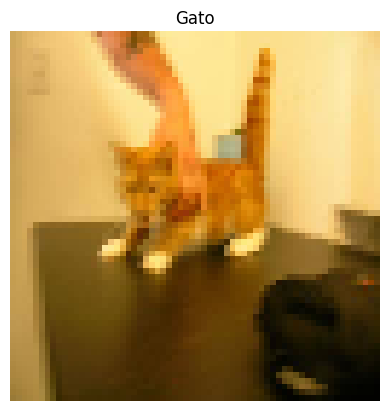

In [5]:
from tensorflow.keras.preprocessing import image
img = image.load_img(f'{train_gatos_dir}/cat.0.jpg',target_size=(64,64))
plt.imshow(img)
plt.title('Gato')
plt.axis('off')
plt.show()

# CREAMOS UN OBJETO QUE APLIQUE DATA AUGMENTATION

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
augmented_data = ImageDataGenerator(
    rescale=1. /255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

## Parámetros de Augmentación de Imágenes

### `rescale=1./255`
Normaliza los valores de los píxeles dividiéndolos entre 255.  

Las imágenes suelen tener valores en el rango `[0, 255]`, y este parámetro los convierte a un rango `[0, 1]`, lo cual es beneficioso para entrenar redes neuronales.  

### `rotation_range=40`
Rota la imagen aleatoriamente hasta 40 grados en ambas direcciones (sentido horario y antihorario).  

Introduce variabilidad en la orientación de los datos de entrenamiento.  

### `width_shift_range=0.2`
Desplaza la imagen horizontalmente hasta un 20% del ancho de la imagen de forma aleatoria.  

Simula variaciones en la posición de los objetos dentro de la imagen.  

### `height_shift_range=0.2`
Desplaza la imagen verticalmente hasta un 20% de la altura de la imagen de forma aleatoria.  

Similar a `width_shift_range`, pero en la dirección vertical.  

### `shear_range=0.2`
Aplica una transformación de cizallamiento (*shear*), que distorsiona la imagen como si se estuviera viendo desde un ángulo inclinado.  

Introduce variabilidad en la perspectiva.  

### `zoom_range=0.2`
Aplica un zoom aleatorio dentro del rango especificado (20% en este caso).  

Simula variaciones en la distancia del objeto respecto a la cámara.  

### `horizontal_flip=True`
Realiza un espejado horizontal aleatorio (voltea la imagen de izquierda a derecha).  

Útil para imágenes donde la orientación izquierda-derecha no es crucial (por ejemplo, fotos de animales o paisajes).  

# APLICAMOS NUESTRO OBJETO PARA GENERAR IMAGENES ALEATORIAS DE LA IMAGEN DE MUESTRA

In [7]:
from tensorflow.keras.preprocessing import image
img = image.load_img(f'{train_gatos_dir}/cat.0.jpg',target_size=(64,64))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

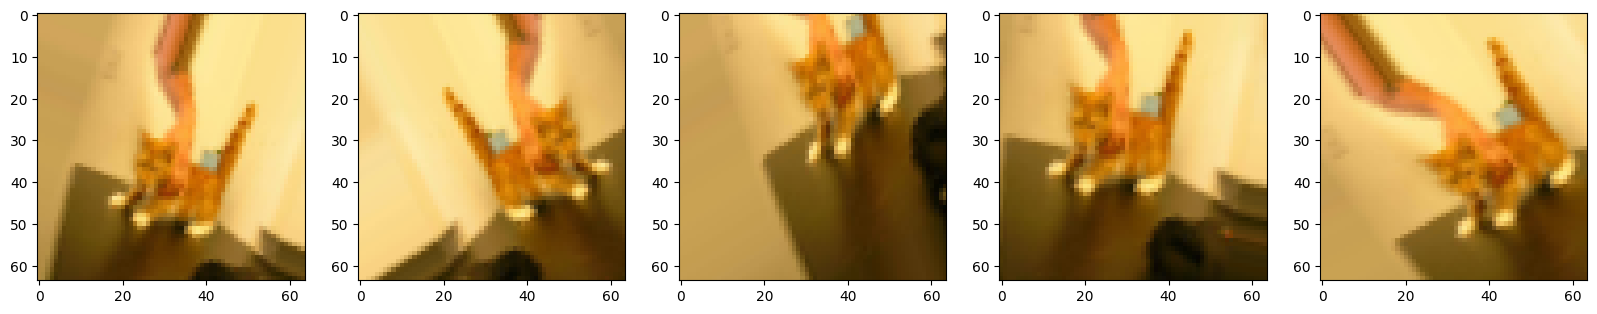

In [8]:
# Generar las imágenes aumentadas
i = 0
fig, ax = plt.subplots(1, 5, figsize=(20, 20))  # Mostrar 5 imágenes aumentadas
for batch in augmented_data.flow(img_array, batch_size=1):
    ax[i].imshow(image.array_to_img(batch[0]))  # Convertir el array a imagen y mostrarla
    i += 1
    if i % 5 == 0:
        break  # Solo mostrar 5 imágenes
plt.show()

# CREAMOS OBJETOS PARA CARGAR EL CONJUNTO DE ENTRENAMIENTO VALIDACIÓN Y PRUEBAS

In [4]:
import tensorflow as tf
print(tf.__version__)

2.19.0


# CREAMOS OBJETOS PARA CARGAR EL CONJUNTO DE ENTRENAMIENTO VALIDACIÓN Y PRUEBAS CON DATA AUGMENTATION

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_data = ImageDataGenerator(rescale=1. /255,
                                    rotation_range=40,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.2,
                                    zoom_range=0.2,
                                    horizontal_flip=True)
val_data = ImageDataGenerator(rescale=1. /255)
test_data = ImageDataGenerator(rescale=1. /255)

## CARGAMOS LOS CONJUNTOS DE DATOS CON LOS OBJETOS CREADOS

In [6]:
training_set = train_data.flow_from_directory(
    TRAIN_DIR,
    target_size=(64,64),
    batch_size=32,
    class_mode='binary'
)
validation_set = train_data.flow_from_directory(
    VALIDATION_DIR,
    target_size=(64,64),
    batch_size=20,
    class_mode='binary'
)
test_set = train_data.flow_from_directory(
    TEST_DIR,
    target_size=(64,64),
    class_mode='binary'
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 2 images belonging to 2 classes.


# CREAMOS MODELO DE RED NEURONAL CONVOLUCIONAL

In [7]:
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

In [8]:
modelo = Sequential()
modelo.add(Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)))
modelo.add(MaxPooling2D((2,2)))
modelo.add(Conv2D(32,(3,3),activation='relu'))
modelo.add(MaxPooling2D((2,2)))
modelo.add(Flatten())
modelo.add(Dense(128,activation='relu'))
modelo.add(Dropout(0.5))
modelo.add(Dense(1,activation='sigmoid'))

modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 813,217 (3.10 MB)

 Trainable params: 813,217 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

# COMPILAR LA RED NEURONAL

In [9]:
modelo.compile(loss="binary_crossentropy",
               optimizer='adam',
               metrics=['accuracy'])

# ENTRENAMOS EL MODELO

In [10]:
history = modelo.fit(training_set,epochs=30,batch_size=100,validation_data=validation_set)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 948s 15s/step - accuracy: 0.4845 - loss: 0.7106 - val_accuracy: 0.5000 - val_loss: 0.7272
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 272ms/step - accuracy: 0.5094 - loss: 0.7002 - val_accuracy: 0.5090 - val_loss: 0.6883
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 275ms/step - accuracy: 0.5630 - loss: 0.6865 - val_accuracy: 0.5990 - val_loss: 0.6835
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 350ms/step - accuracy: 0.5688 - loss: 0.6806 - val_accuracy: 0.6000 - val_loss: 0.6669
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 276ms/step - accuracy: 0.6151 - loss: 0.6607 - val_accuracy: 0.6320 - val_loss: 0.6394
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 269ms/step - accuracy: 0.5963 - loss: 0.6576 - val_accuracy: 0.6520 - val_loss: 0.6252
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 272ms/step - accuracy: 0.6177 - loss: 0.6564 - val_accuracy: 0.5880 - val_loss: 0.6509
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 269ms/step - accuracy: 0.6359 - loss: 0.6424 - val_accur

# EVALUAMOS EL MODELO

In [11]:
evaluacion = modelo.evaluate(test_set)
print(evaluacion)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step - accuracy: 0.5000 - loss: 0.5293
[0.5292601585388184, 0.5]


# REALIZAMOS PREDICCIÓN DEL MODELO

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
predicción :  [[0.]]
Es un gato


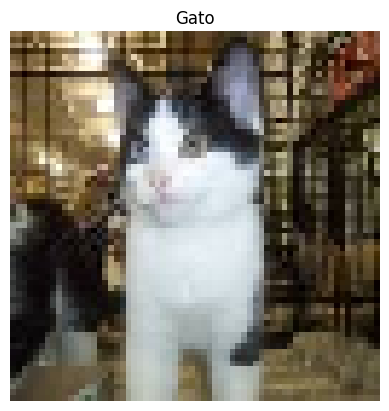

In [13]:
from keras.preprocessing import image
gato = image.load_img(test_gatos_dir + "/cat.1000.jpg",target_size=(64,64))
perro = image.load_img(test_perros_dir + "/dog.1000.jpg",target_size=(64,64))
imagen_prueba = gato

test_image = image.img_to_array(imagen_prueba)
test_image = np.expand_dims(test_image,axis=0)
training_set.class_indices


result = modelo.predict(test_image)
print("predicción : ",result)
if result[0][0] == 0:
  print("Es un gato")
  plt.imshow(imagen_prueba)
  plt.title('Gato')
  plt.axis('off')
  plt.show()
else:
  print("Es un perro")
  plt.imshow(imagen_prueba)
  plt.title('Perro')
  plt.axis('off')
  plt.show()

# GRAFICAMOS ACCURACY Y LOSS

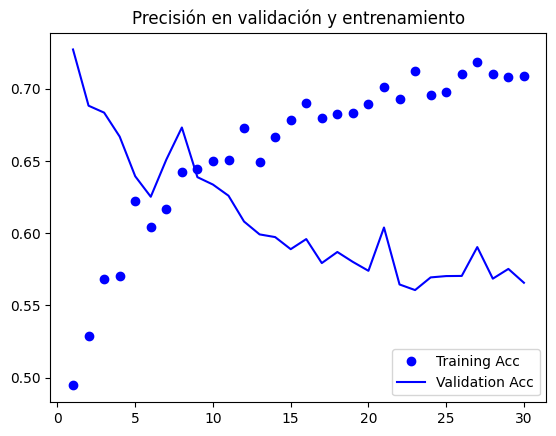

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_loss']
epochs = range(1,len(acc)+1)

plt.plot(epochs,acc,'bo',label='Training Acc')
plt.plot(epochs,val_acc,'b',label='Validation Acc')
plt.title('Precisión en validación y entrenamiento')
plt.legend()
plt.show()

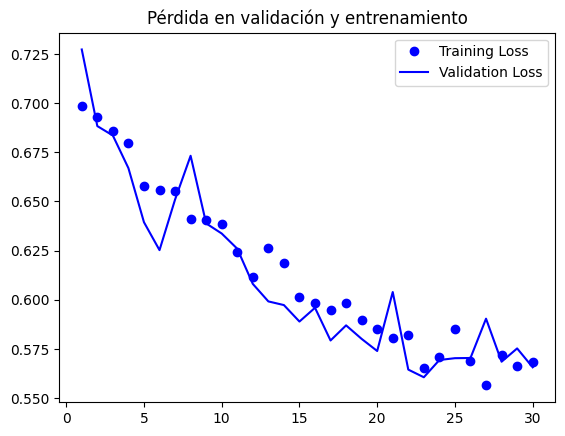

In [15]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1,len(acc)+1)

plt.plot(epochs,loss,'bo',label='Training Loss')
plt.plot(epochs,val_loss,'b',label='Validation Loss')
plt.title('Pérdida en validación y entrenamiento')
plt.legend()
plt.show()

# GUARDAMOS EL MODELO ENTRENADO

In [16]:
modelo.save("modelo_perrosygatos.keras")